Mediante el Bagging conseguimos que los errores se compensen debido a que cada modelo se entrena con subconjuntos que eligen muestras de con repetición de una manera totalmente aleatoria.

## 1. ¿Qué es Random Forest?
Random Forest es un algoritmo de aprendizaje automático basado en la técnica de ensamblaje, que combina múltiples árboles de decisión para mejorar la precisión y controlar el sobreajuste. Es especialmente útil para tareas de clasificación y regresión.

## 2. Componentes Clave
- **Árboles de Decisión**: Un árbol de decisión es una estructura de decisión en forma de árbol que divide los datos en función de características específicas para hacer predicciones.
- **Ensamble**: Random Forest utiliza un conjunto de árboles de decisión para tomar decisiones más robustas. Cada árbol se entrena con una muestra diferente de los datos.

## 3. Cómo Funciona Random Forest
- **Bootstrap Sampling**: Se generan múltiples subconjuntos de datos (muestras) a partir del conjunto de entrenamiento original usando el método de muestreo bootstrap (muestra con reemplazo).
- **Creación de Árboles**: Para cada subconjunto, se construye un árbol de decisión. Durante la construcción, en cada división del árbol se selecciona aleatoriamente un subconjunto de características, lo que introduce diversidad entre los árboles.
- **Predicción**: Para la clasificación, cada árbol vota por una clase y la clase más votada es la predicción final. Para regresión, se promedia la salida de todos los árboles.

## 4. Ventajas de Random Forest
- **Robustez**: Al promediar múltiples modelos, Random Forest es menos susceptible a sobreajuste que un único árbol de decisión.
- **Manejo de Datos Faltantes**: Puede manejar datos faltantes sin necesidad de imputación.
- **Importancia de las Características**: Proporciona medidas de importancia de características, lo que ayuda a entender cuáles son relevantes para la predicción.

## 5. Desventajas
- **Interpretabilidad**: Aunque cada árbol es interpretable, el modelo global de Random Forest puede ser más difícil de entender.
- **Requerimientos Computacionales**: Puede ser más lento que otros algoritmos, especialmente con muchos árboles y grandes conjuntos de datos.

## 6. Parámetros Clave
- **n\_estimators**: Número de árboles en el bosque.
- **max\_depth**: Profundidad máxima de los árboles.
- **min\_samples\_split**: Número mínimo de muestras requeridas para dividir un nodo.
- **min\_samples\_leaf**: Número mínimo de muestras requeridas para estar en un nodo hoja.
- **max\_features**: Número máximo de características a considerar para buscar la mejor división.

## Conclusión
Random Forest es un algoritmo potente y versátil en el arsenal del aprendizaje automático. Su capacidad para manejar datos de alta dimensión y su robustez lo convierten en una excelente opción para diversas aplicaciones.

### Bagging

Utiliza un sistema paralelo.

"Bootstrap Aggregating", es un método que mejora la estabilidad y precisión de los algoritmos de aprendizaje automático. Se utiliza principalmente con modelos que tienden a tener alta varianza, como los árboles de decisión.

El principal objetivo de bagging es reducir la varianza del modelo combinando las predicciones de varios modelos entrenados de forma independiente.

Error cuadrático medio del modelo: 0.29


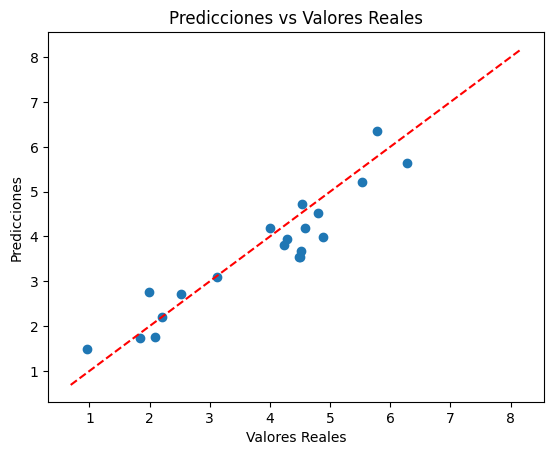

In [ ]:
# Importar bibliotecas necesarias
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Generar un conjunto de datos sintético
np.random.seed(42)
X = np.random.rand(100, 2)  # 100 muestras, 2 características
y = 3 * X[:, 0] + 5 * X[:, 1] + np.random.normal(0, 0.5, 100)  # Relación lineal con ruido

# Convertir a DataFrame
data = pd.DataFrame(X, columns=['Feature1', 'Feature2'])
data['Target'] = y

# Dividir el conjunto de datos
X_train, X_test, y_train, y_test = train_test_split(data[['Feature1', 'Feature2']], data['Target'], test_size=0.2, random_state=42)

# Crear y entrenar el modelo
rf = RandomForestRegressor(n_estimators=100, random_state=42)  #Estos hiperparametros se eligen arbitrariamente sólo a modo de ejemplo
rf.fit(X_train, y_train)

# Hacer predicciones
y_pred = rf.predict(X_test)

# Evaluar el modelo
mse = mean_squared_error(y_test, y_pred)
print(f'Error cuadrático medio del modelo: {mse:.2f}')

# Visualizar las predicciones
plt.scatter(y_test, y_pred)
plt.xlabel('Valores Reales')
plt.ylabel('Predicciones')
plt.title('Predicciones vs Valores Reales')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--')
plt.show()

Error cuadrático medio del modelo: 0.21


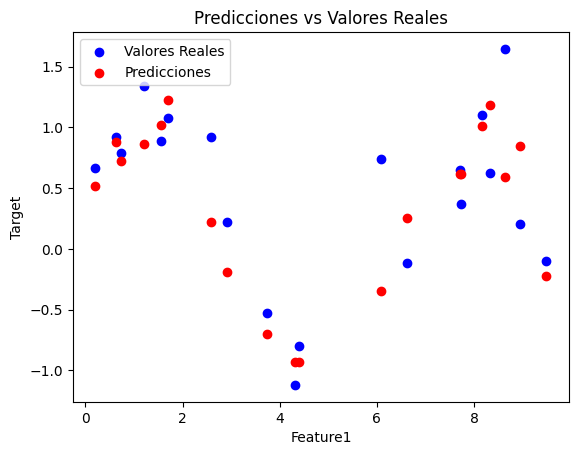

In [ ]:
# Importar bibliotecas necesarias
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Generar un conjunto de datos sintético no lineal
cant=100
np.random.seed(42)
X = np.random.rand(cant, 1) * 10  # 100 muestras, 1 característica
y = np.sin(X).ravel() + np.random.normal(0, 0.5, cant)  # Relación no lineal con ruido

# Convertir a DataFrame
data = pd.DataFrame(X, columns=['Feature1'])
data['Target'] = y

# Dividir el conjunto de datos
X_train, X_test, y_train, y_test = train_test_split(data[['Feature1']], data['Target'], test_size=0.2, random_state=42)

# Crear y entrenar el modelo
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Hacer predicciones
y_pred = rf.predict(X_test)

# Evaluar el modelo
mse = mean_squared_error(y_test, y_pred)
print(f'Error cuadrático medio del modelo: {mse:.2f}')

# Visualizar las predicciones
plt.scatter(X_test, y_test, color='blue', label='Valores Reales')
plt.scatter(X_test, y_pred, color='red', label='Predicciones')
plt.xlabel('Feature1')
plt.ylabel('Target')
plt.title('Predicciones vs Valores Reales')
plt.legend()
plt.show()

# Bootstrap Sampling

## ¿Qué es el Bootstrap Sampling?

El **Bootstrap Sampling** es una técnica de muestreo utilizada en estadística y aprendizaje automático. Consiste en generar múltiples conjuntos de datos a partir de un conjunto de datos original, permitiendo el muestreo con reemplazo. Esta técnica es fundamental para métodos de ensamblaje, como Random Forest, ya que ayuda a reducir el sobreajuste y a estimar la variabilidad del modelo.

## Proceso de Bootstrap Sampling

El proceso de Bootstrap Sampling se lleva a cabo en los siguientes pasos:

1. **Seleccionar un conjunto de datos original**: Comenzamos con un conjunto de datos que contiene $N$ observaciones.

2. **Generar muestras**: Para crear una muestra bootstrap, se seleccionan $n$ observaciones del conjunto original, donde $n \leq N$. Cada observación se elige al azar y se puede seleccionar más de una vez (esto es, el muestreo es con reemplazo). Así, la muestra puede tener menos de $n$ observaciones únicas.

3. **Repetir el proceso**: Este proceso se repite $B$ veces (por ejemplo, 100 o 1000 veces), generando así $B$ diferentes conjuntos de datos bootstrap.

## Propiedades del Bootstrap Sampling

- **Estimación de la Varianza**: El Bootstrap Sampling permite estimar la varianza de una estadística (como la media o la mediana) al calcularla en múltiples muestras. Esto se logra calculando la estadística de interés en cada uno de los conjuntos bootstrap y luego tomando la desviación estándar de esos valores.

- **Flexibilidad**: Esta técnica no requiere suposiciones sobre la distribución de los datos, lo que la hace adecuada para una amplia variedad de aplicaciones.

## Ejemplo Visual

A continuación, se presenta un ejemplo visual del proceso de Bootstrap Sampling:

1. **Conjunto de Datos Original**: Imaginemos que tenemos un conjunto de datos con 10 observaciones.

2. **Muestra Bootstrap**: Al seleccionar aleatoriamente con reemplazo, podríamos obtener un conjunto de datos bootstrap que contenga repeticiones de algunas observaciones.

3. **Repetición**: Este proceso se repite varias veces para generar diferentes conjuntos de datos bootstrap.

Media de la población original: 48.96
Media de las muestras bootstrap: 48.98


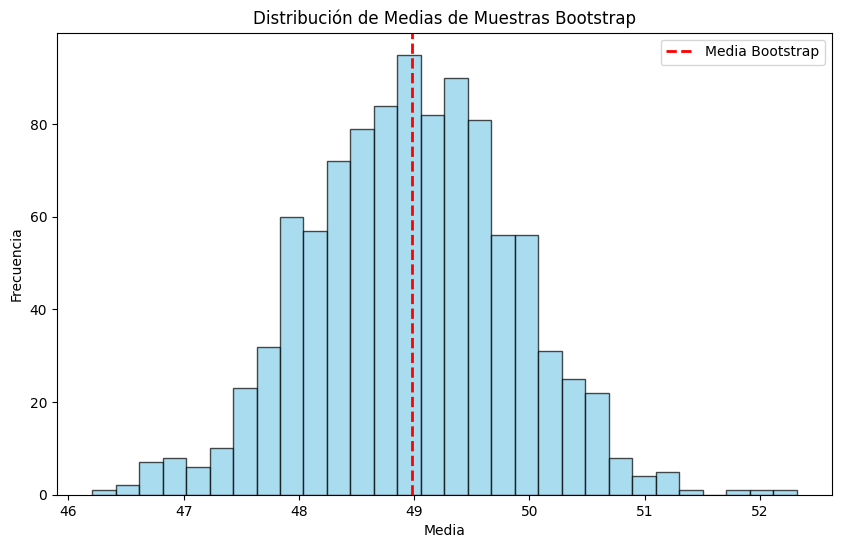

In [ ]:
# Importar bibliotecas necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Generar un conjunto de datos sintético
np.random.seed(42)
data = np.random.normal(loc=50, scale=10, size=100)  # 100 muestras de una distribución normal

# Función para realizar Bootstrap Sampling
def bootstrap_sampling(data, n_iterations=1000, sample_size=None):
    if sample_size is None:
        sample_size = len(data)

    means = []

    for _ in range(n_iterations):
        # Crear una muestra bootstrap
        sample = np.random.choice(data, size=sample_size, replace=True)
        # Calcular la media de la muestra
        means.append(np.mean(sample))

    return means

# Realizar Bootstrap Sampling
n_iterations = 1000
bootstrap_means = bootstrap_sampling(data, n_iterations=n_iterations)

# Calcular la media y el intervalo de confianza
mean_of_means = np.mean(bootstrap_means)
conf_interval = np.percentile(bootstrap_means, [2.5, 97.5])

# Resultados
print(f'Media de la población original: {np.mean(data):.2f}')
print(f'Media de las muestras bootstrap: {mean_of_means:.2f}')

# Visualizar los resultados
plt.figure(figsize=(10, 6))
plt.hist(bootstrap_means, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(mean_of_means, color='red', linestyle='dashed', linewidth=2, label='Media Bootstrap')
plt.title('Distribución de Medias de Muestras Bootstrap')
plt.xlabel('Media')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()

Mejores hiperparámetros encontrados:
{'max_depth': 5, 'min_samples_split': 10, 'n_estimators': 200}
Error cuadrático medio del modelo: 0.18


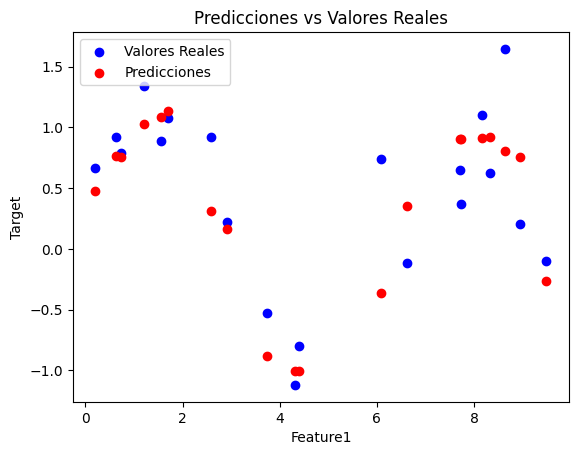

In [ ]:
# Importar bibliotecas necesarias
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Generar un conjunto de datos sintético no lineal
np.random.seed(42)
X = np.random.rand(100, 1) * 10  # 100 muestras, 1 característica
y = np.sin(X).ravel() + np.random.normal(0, 0.5, 100)  # Relación no lineal con ruido

# Dividir el conjunto de datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Definir el modelo
rf = RandomForestRegressor(random_state=42)

# Definir los hiperparámetros para la búsqueda
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10],
}

# Configurar la búsqueda de hiperparámetros con Cross-Validation
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

# Ajustar el modelo a los datos de entrenamiento
grid_search.fit(X_train, y_train)

# Mostrar los mejores hiperparámetros encontrados
best_params = grid_search.best_params_
print("Mejores hiperparámetros encontrados:")
print(best_params)

# Predecir con el mejor modelo
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)

# Evaluar el modelo
mse = mean_squared_error(y_test, y_pred)
print(f'Error cuadrático medio del modelo: {mse:.2f}')

# Visualizar las predicciones
plt.scatter(X_test, y_test, color='blue', label='Valores Reales')
plt.scatter(X_test, y_pred, color='red', label='Predicciones')
plt.xlabel('Feature1')
plt.ylabel('Target')
plt.title('Predicciones vs Valores Reales')
plt.legend()
plt.show()

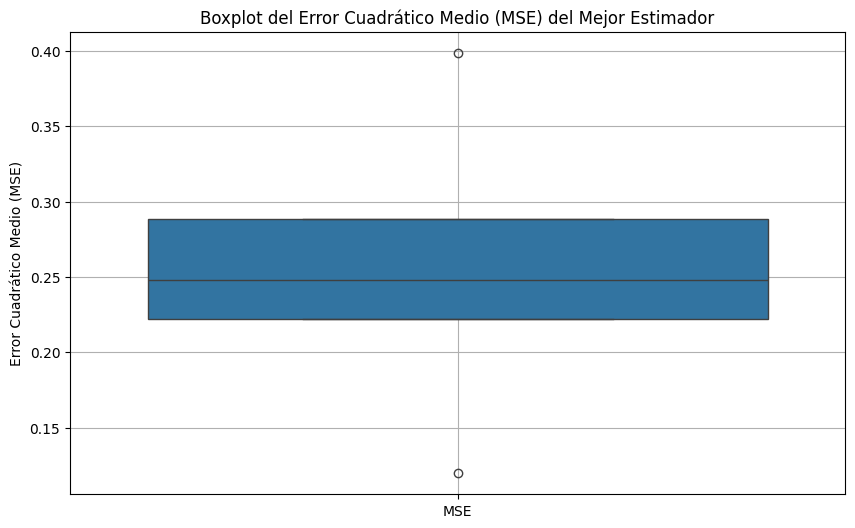

In [ ]:
import seaborn as sns

# Evaluar el mejor modelo usando validación cruzada
from sklearn.model_selection import cross_val_score

# Realizar validación cruzada con el mejor estimador
cv_scores = cross_val_score(best_rf, X_train, y_train, cv=5, scoring='neg_mean_squared_error')

# Convertir los scores a valores positivos
mse_scores = -cv_scores

# Crear un boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=mse_scores)
plt.title('Boxplot del Error Cuadrático Medio (MSE) del Mejor Estimador')
plt.ylabel('Error Cuadrático Medio (MSE)')
plt.xticks([0], ['MSE'])
plt.grid()
plt.show()

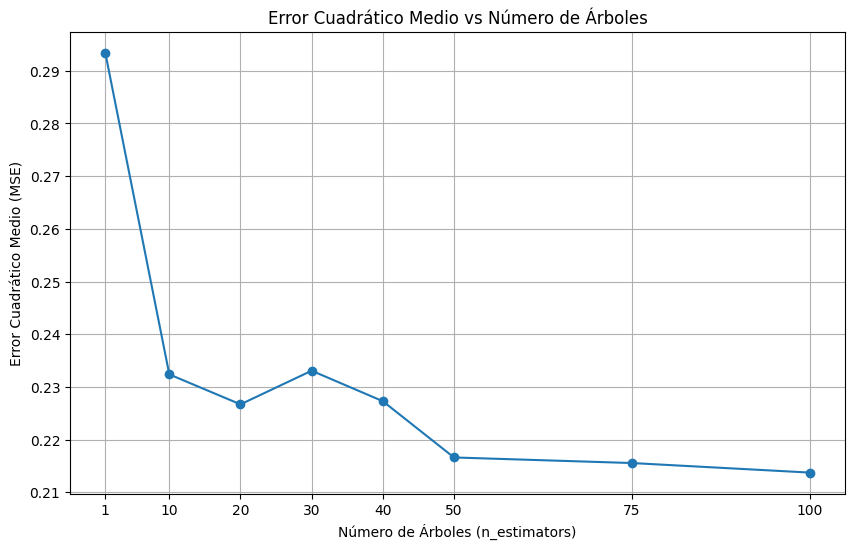

In [ ]:
# Importar bibliotecas necesarias
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Generar un conjunto de datos sintético no lineal
np.random.seed(42)
X = np.random.rand(100, 1) * 10  # 100 muestras, 1 característica
y = np.sin(X).ravel() + np.random.normal(0, 0.5, 100)  # Relación no lineal con ruido

# Dividir el conjunto de datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Lista para almacenar el error cuadrático medio
mse_values = []
n_estimators_range = [1, 10, 20, 30, 40,50,75,100]  # Diferentes cantidades de árboles

# Evaluar el modelo para diferentes números de árboles
for n in n_estimators_range:
    rf = RandomForestRegressor(n_estimators=n, random_state=42)
    rf.fit(X_train, y_train)  # Ajustar el modelo
    y_pred = rf.predict(X_test)  # Predecir
    mse = mean_squared_error(y_test, y_pred)  # Calcular MSE
    mse_values.append(mse)  # Almacenar MSE

# Graficar el error cuadrático medio
plt.figure(figsize=(10, 6))
plt.plot(n_estimators_range, mse_values, marker='o')
plt.title('Error Cuadrático Medio vs Número de Árboles')
plt.xlabel('Número de Árboles (n_estimators)')
plt.ylabel('Error Cuadrático Medio (MSE)')
plt.xticks(n_estimators_range)
plt.grid()
plt.show()